## CIFAR-10 Image Classification

In [3]:
## 1. Imports & Setup
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, Sequential, optimizers
from tensorflow.keras.datasets import cifar10
from keras.layers import Dense, Activation, Flatten, Dropout, BatchNormalization,Conv2D, MaxPooling2D
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import cv2
from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [4]:
## 2. Load CIFAR-10 Dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

print(f"Images Shape {x_train.shape}", f"\nLabels {y_train.shape}")

### Class Labels

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

Images Shape (50000, 32, 32, 3) 
Labels (50000, 1)


In [5]:
# Break training set into training and validation sets
(x_train, x_valid) = x_train[5000:], x_train[:5000]
(y_train, y_valid) = y_train[5000:], y_train[:5000]

# Print shapes
print(x_train.shape[0], 'train samples')
print(x_valid.shape[0], 'validation samples')
print(x_test.shape[0], 'test samples')

45000 train samples
5000 validation samples
10000 test samples


In [6]:
# Normalize the data
mean = np.mean(x_train,axis=(0,1,2,3))
std = np.std(x_train,axis=(0,1,2,3))
x_train = (x_train-mean)/(std+1e-7)
x_valid = (x_valid-mean)/(std+1e-7)
x_test = (x_test-mean)/(std+1e-7)

In [7]:
# Convert labels to categorical
num_classes = len(np.unique(y_train)) 
print(num_classes)
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_valid = tf.keras.utils.to_categorical(y_valid, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)
print(f"Images Train Shape {x_train.shape}", f"\nLabels {y_train.shape}")
print(f"Images Valid Shape {x_valid.shape}", f"\nLabels {y_valid.shape}")
print(f"Images Test Shape {x_test.shape}", f"\nLabels {y_test.shape}")

10
Images Train Shape (45000, 32, 32, 3) 
Labels (45000, 10)
Images Valid Shape (5000, 32, 32, 3) 
Labels (5000, 10)
Images Test Shape (10000, 32, 32, 3) 
Labels (10000, 10)


In [8]:
## 4. Data Augmentation 
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=False
)
datagen.fit(x_train)

In [9]:
base_hidden_units = 32    
weight_decay = 1e-4    
model = Sequential() 

# CONV1
model.add(Conv2D(base_hidden_units, kernel_size= 3, padding='same',   
 kernel_regularizer=regularizers.l2(weight_decay),    
input_shape=x_train.shape[1:]))
model.add(Activation('relu'))     
model.add(BatchNormalization())  

# CONV2
model.add(Conv2D(base_hidden_units, kernel_size= 3, padding='same', 
 kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())

# POOL + Dropout
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))   

# CONV3
model.add(Conv2D(base_hidden_units * 2, kernel_size= 3, padding='same',    
 kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())

# CONV4
model.add(Conv2D(base_hidden_units * 2, kernel_size= 3, padding='same', 
 kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())

# POOL + Dropout
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.3))

# CONV5
model.add(Conv2D(base_hidden_units * 4, kernel_size= 3, padding='same', 
 kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())

# CONV6
model.add(Conv2D(base_hidden_units * 4, kernel_size= 3, padding='same',
 kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())

# POOL + Dropout
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

# FC7
model.add(Flatten())    
model.add(Dense(num_classes, activation='softmax'))    

model.summary() 

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 activation (Activation)     (None, 32, 32, 32)        0         
                                                                 
 batch_normalization (Batch  (None, 32, 32, 32)        128       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 32)        9248      
                                                                 
 activation_1 (Activation)   (None, 32, 32, 32)        0         
                                                                 
 batch_normalization_1 (Bat  (None, 32, 32, 32)        128       
 chNormalization)                                       

In [10]:
## 6. Compile the Model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
## 7. Callbacks
checkpoint = ModelCheckpoint(
    r"E:\CIFAR-10 Image Classification\model.weights.best.hdf5",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)


In [164]:
## 8. Train the Model
EPOCHS = 50
BATCH_SIZE = 64

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=x_train.shape[0] // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_valid, y_valid),
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)
print("\n✓Complete!")

Epoch 1/50
703/703 [==============================] - ETA: 0s - loss: 2.6775 - accuracy: 0.2900
Epoch 1: val_loss improved from inf to 1.59185, saving model to E:\CIFAR-10 Image Classification\model.weights.best.hdf5
703/703 [==============================] - 193s 272ms/step - loss: 2.6775 - accuracy: 0.2900 - val_loss: 1.5918 - val_accuracy: 0.4734 - lr: 1.0000e-04
Epoch 2/50


C:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


703/703 [==============================] - ETA: 0s - loss: 1.9918 - accuracy: 0.3746
Epoch 2: val_loss improved from 1.59185 to 1.49935, saving model to E:\CIFAR-10 Image Classification\model.weights.best.hdf5
703/703 [==============================] - 192s 274ms/step - loss: 1.9918 - accuracy: 0.3746 - val_loss: 1.4994 - val_accuracy: 0.4908 - lr: 1.0000e-04
Epoch 3/50
703/703 [==============================] - ETA: 0s - loss: 1.7867 - accuracy: 0.4179
Epoch 3: val_loss improved from 1.49935 to 1.42577, saving model to E:\CIFAR-10 Image Classification\model.weights.best.hdf5
703/703 [==============================] - 197s 280ms/step - loss: 1.7867 - accuracy: 0.4179 - val_loss: 1.4258 - val_accuracy: 0.5122 - lr: 1.0000e-04
Epoch 4/50
703/703 [==============================] - ETA: 0s - loss: 1.6487 - accuracy: 0.4597
Epoch 4: val_loss did not improve from 1.42577
703/703 [==============================] - 191s 272ms/step - loss: 1.6487 - accuracy: 0.4597 - val_loss: 1.4320 - val_accu

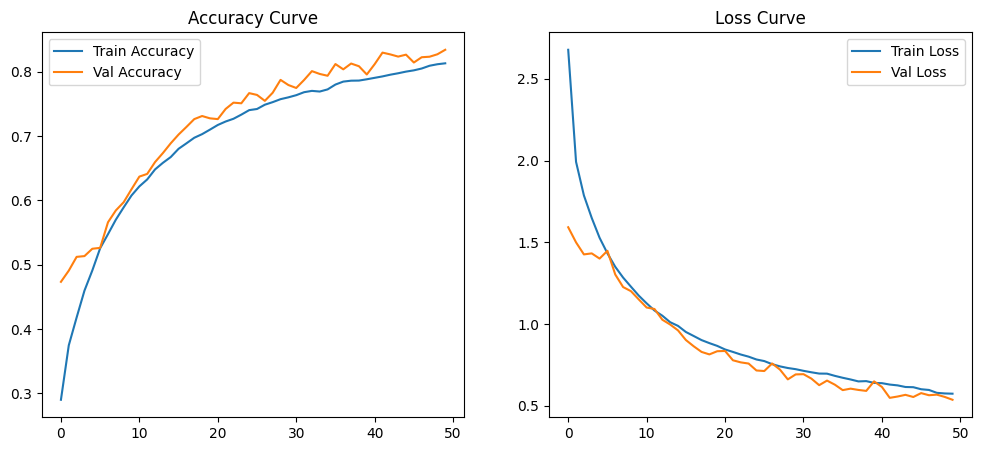

In [165]:
## 9. Accuracy & Loss Curves

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy Curve')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Curve')

plt.show()

In [168]:
## 10. Evaluate on Test Data

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")

Test Accuracy: 81.69%


313/313 [==============================] - 8s 26ms/step


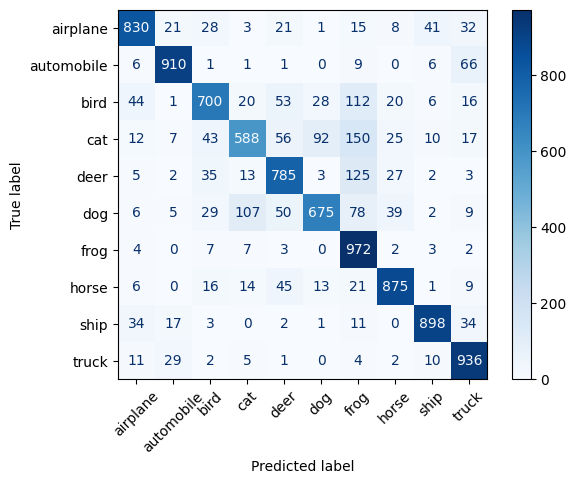

In [178]:
## 12. Confusion Matrix

y_pred = model.predict(x_test).argmax(axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.show()

In [199]:
def predict_external_image(image_path):
    
    img = cv2.imread(image_path)
    
    if img is None:
        print("Error: Image not found!")
        return
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (32, 32))
    img = img.astype('float32')
    img = (img - mean) / (std + 1e-7)
    img_input = np.expand_dims(img, axis=0)
    
    prediction = model.predict(img_input)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100
    
    img_display = (img * std + mean).astype("uint8")
    
    plt.imshow(img_display)
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()
    
    return predicted_class


1/1 [==============================] - 0s 20ms/step


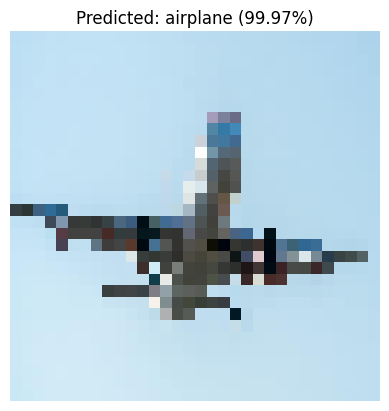

'airplane'

In [ ]:
predict_external_image("test_images\test1.jpg")

1/1 [==============================] - 0s 23ms/step


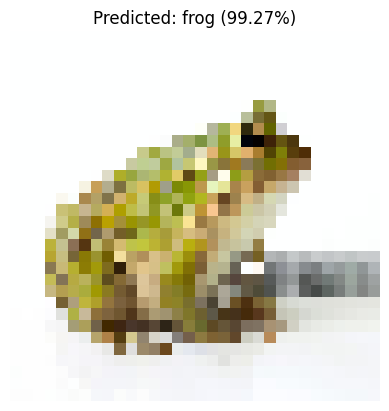

'frog'

In [ ]:
predict_external_image("test_images\test2.jpg")

1/1 [==============================] - 0s 20ms/step


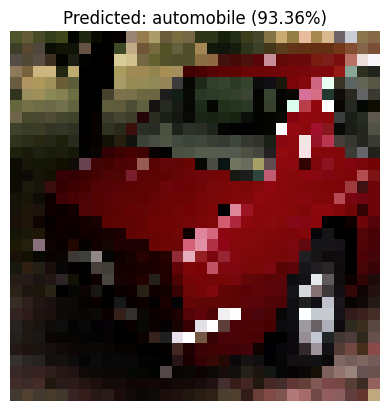

'automobile'

In [ ]:
predict_external_image("test_images\test3.jpg")

1/1 [==============================] - 0s 20ms/step


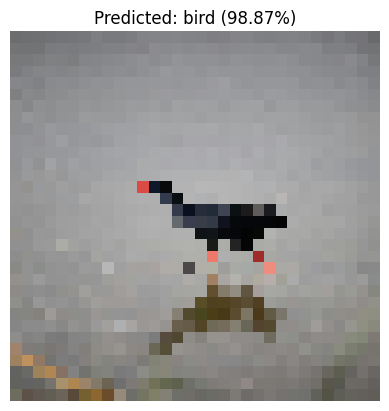

'bird'

In [ ]:
predict_external_image("test_images\test4.jpg")

1/1 [==============================] - 0s 20ms/step


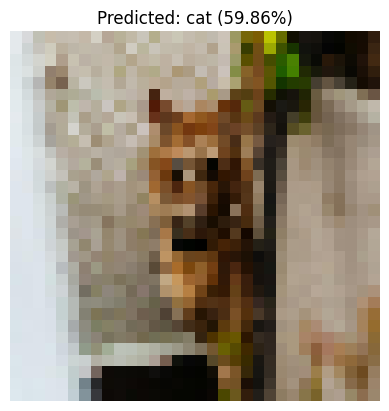

'cat'

In [ ]:
predict_external_image("test_images\test5.jpg")

1/1 [==============================] - 0s 27ms/step


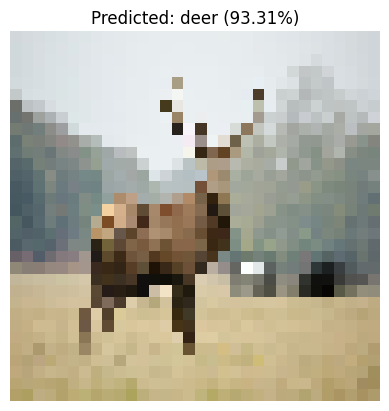

'deer'

In [ ]:
predict_external_image("test_images\test6.jpg")

1/1 [==============================] - 0s 20ms/step


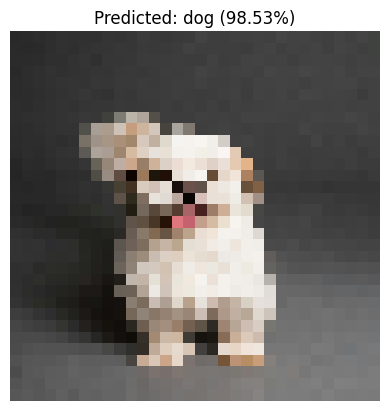

'dog'

In [ ]:
predict_external_image("test_images\test7.jpg")

1/1 [==============================] - 0s 23ms/step


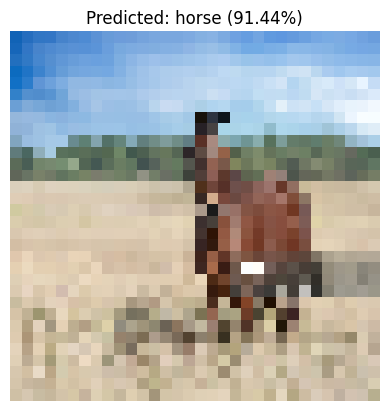

'horse'

In [ ]:
predict_external_image("test_images\test8.jpg")

1/1 [==============================] - 0s 21ms/step


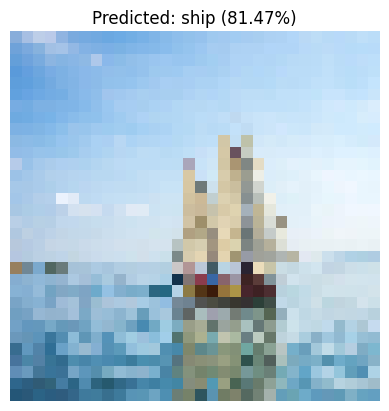

'ship'

In [ ]:
predict_external_image("test_images\test9.jpg")

1/1 [==============================] - 0s 20ms/step


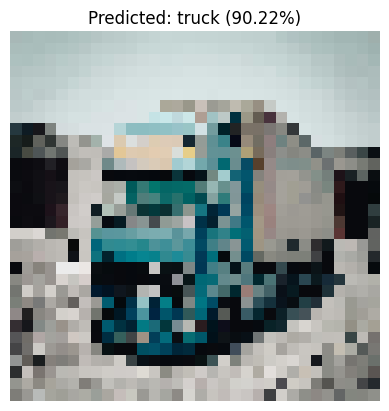

'truck'

In [ ]:
predict_external_image("test_images\test10.jpg")